# Momentum-based Gradient Descent 

In [150]:
import numpy as np
import matplotlib.pyplot as plt

## Defining a quadratic loss function
x and y here are not input and output, they are **two parameters** in a loss function.

In [151]:
def quadratic_loss(x, y):
    return x**2 + 10 * y**2 #Ellipse

## Gradient of the loss function

In [152]:
def quadratic_grad(x, y):
    dx = 2*x
    dy = 20*y
    return np.array([dx, dy])

## Batch Gradient Descent (BGD)

In [153]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
    x, y = start_point
    path = [(x, y)]
    losses = [quadratic_loss(x, y)]

    for _ in range(epochs):
        grad = grad_func(x,y)
        x -= eta*grad[0] #Partial Derivative to x
        y -= eta*grad[1] #Partial derivatice to y
        path.append((x,y))
        losses.append(quadratic_loss(x,y))

    return np.array(path), losses

## Gradient Descent with Momentum

In [154]:
def gradient_descent_momentum(grad_func, eta, beta, epochs, start_point):
    x, y = start_point
    path = [(x,y)]
    losses = [quadratic_loss(x,y)]
    v=0

    for _ in range(epochs):
        grad = grad_func(x,y)
        v = beta * v + (1-beta)*grad # Velocity
        x -= eta*v[0] #Partial derivative to x
        y -= eta*v[1] #Partial derivatice to y
        path.append((x,y))
        losses.append(quadratic_loss(x,y))

    return np.array(path), losses


## Parameters

In [155]:
eta_bgd = 0.1 # Learning rate for BGD
eta_momentum = 0.1 #Learning rate for momentum
beta = 0.9 # Momentum coefficient
epochs = 50
start_point = (1.5, 1.5) # Inital point far from the minimum

## Plot results

In [156]:
def plot_paths(function, paths, labels, title):
    X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8,6))
    plt.contour(X, Y, Z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green', label='Start')
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label='End')

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

In [157]:
def plot_losses(losses, labels, title):
    plt.figure(figsize=(8,6))
    
    for loss, label in zip(losses, labels):
        plt.plot(loss, label=label)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()
    

## Run optimizations

In [158]:
path_bgd, losses_bgd = batch_gradient_descent(quadratic_grad, eta_bgd, epochs, start_point)
path_momentum, losses_momentum = gradient_descent_momentum(quadratic_grad, eta_momentum, beta, epochs, start_point)

## Plotting the optimized result

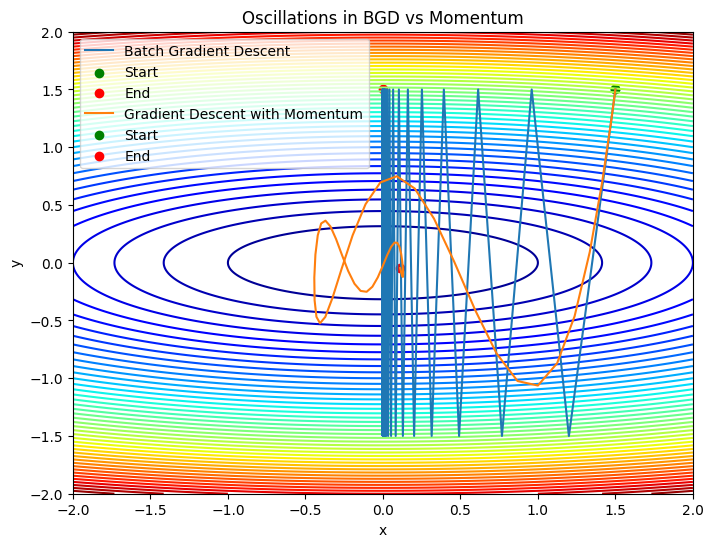

In [159]:
plot_paths(quadratic_loss, [path_bgd, path_momentum], ["Batch Gradient Descent", "Gradient Descent with Momentum"], "Oscillations in BGD vs Momentum")